# Deep Learning Classification Model for Fault & Social Issue Detection

This notebook trains a deep learning model to classify images of faults and social issues (garbage, sewage, potholes, vandalism, etc.) with >90% accuracy using transfer learning.

## 1. Import Required Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.models import resnet50, efficientnet_b2

# Metrics and Evaluation
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder

# Progress bar
from tqdm import tqdm
from PIL import Image

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"GPU Available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1
Device: cuda
GPU Available: True


## 2. Load and Explore the Dataset

Total images: 9660

Class distribution:
label
Broken Road Sign Issues                      1793
Damaged Road issues                           677
Illegal Parking Issues                        104
Littering Garbage on Public Places Issues    1419
Mixed Issues                                  191
Pothole Issues                               3348
Vandalism Issues                             2128
Name: count, dtype: int64


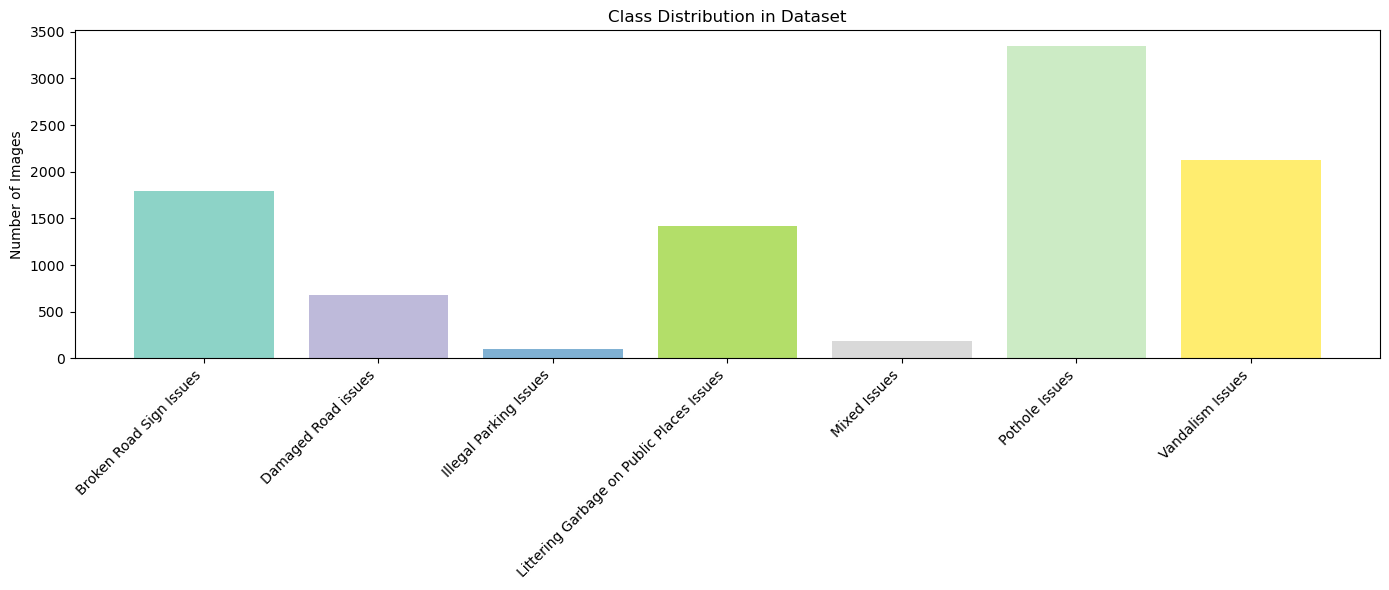


Class imbalance ratio: 32.19x


In [2]:
# Define dataset paths
dataset_root = Path(r'd:\dl+nlp\archive (2)\data')

# Collect all image paths and labels
image_paths = []
labels = []
class_names = []
class_counts = {}

for class_dir in sorted(dataset_root.rglob('*')):
    if class_dir.is_dir() and any(class_dir.glob('*.jpg')):
        class_name = class_dir.name
        class_names.append(class_name)
        count = 0
        for img_path in class_dir.glob('*.jpg'):
            image_paths.append(str(img_path))
            labels.append(class_name)
            count += 1
        class_counts[class_name] = count

# Convert to DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df['label'].value_counts().sort_index())

# Visualize class distribution
fig, ax = plt.subplots(figsize=(14, 6))
class_dist = df['label'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
ax.bar(range(len(class_dist)), class_dist.values, color=colors)
ax.set_xticks(range(len(class_dist)))
ax.set_xticklabels(class_dist.index, rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution in Dataset')
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio: {class_dist.max() / class_dist.min():.2f}x")

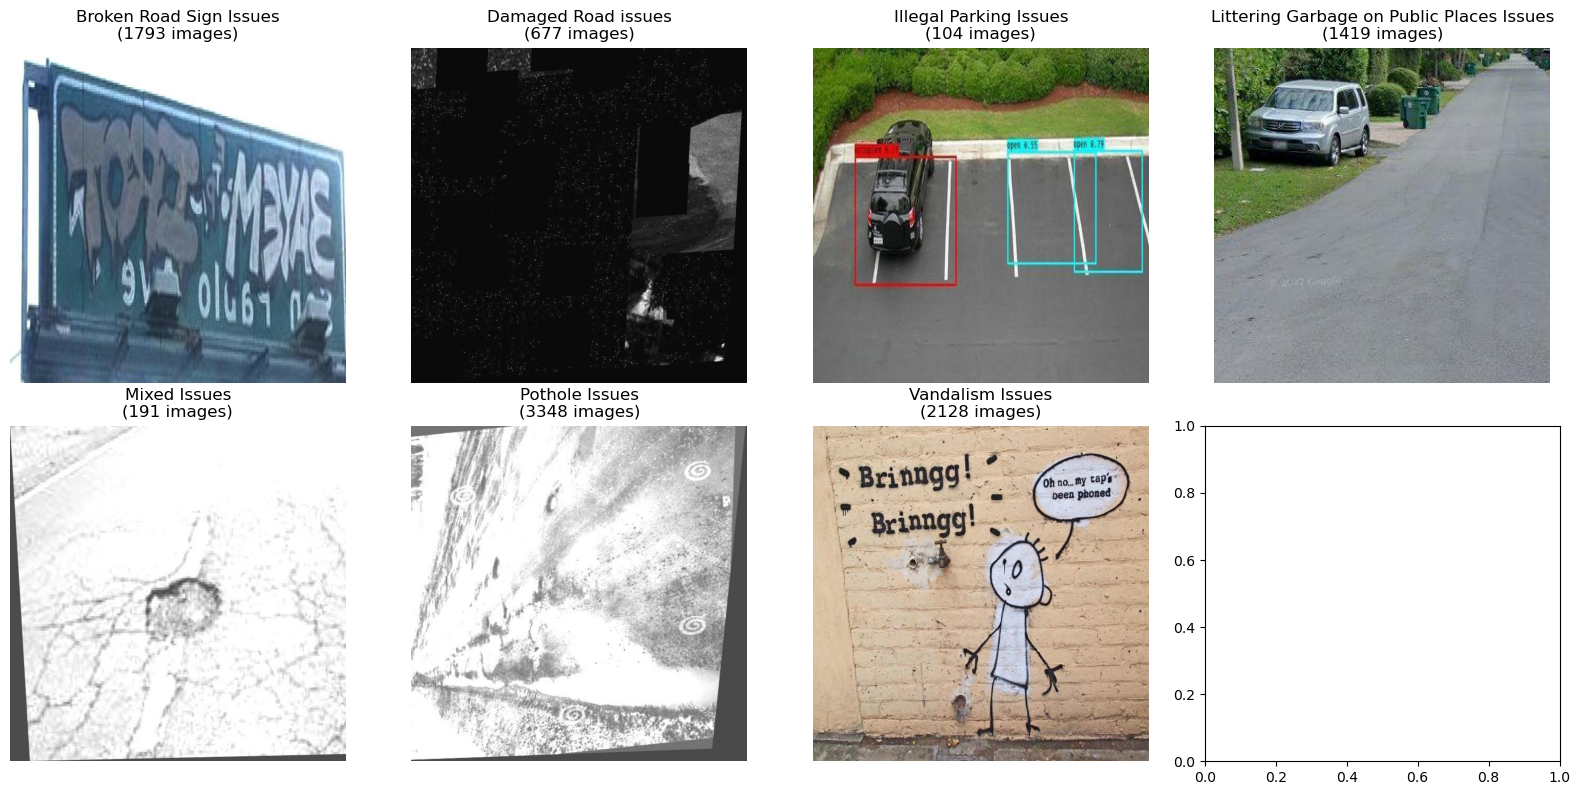

In [3]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, class_name in enumerate(sorted(df['label'].unique())[:8]):
    sample_img_path = df[df['label'] == class_name]['image_path'].iloc[0]
    img = Image.open(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_name}\n({df[df['label'] == class_name].shape[0]} images)")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. Preprocess and Augment Images

In [4]:
# Preprocessing parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])
class_names_sorted = label_encoder.classes_
num_classes = len(class_names_sorted)

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight('balanced', 
                                            classes=np.unique(df['label_encoded']),
                                            y=df['label_encoded'])
class_weights = torch.from_numpy(class_weights_array).float().to(device)

print("Class weights (higher = fewer samples):")
for idx, class_name in enumerate(class_names_sorted):
    print(f"  {class_name}: {class_weights[idx]:.3f}")

# Train/Val/Test split (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (val+test)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# Second split: 50% val, 50% test from temp
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nDataset split:")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Class weights (higher = fewer samples):
  Broken Road Sign Issues: 0.770
  Damaged Road issues: 2.038
  Illegal Parking Issues: 13.269
  Littering Garbage on Public Places Issues: 0.973
  Mixed Issues: 7.225
  Pothole Issues: 0.412
  Vandalism Issues: 0.648

Dataset split:
  Train: 6762 (70.0%)
  Val:   1449 (15.0%)
  Test:  1449 (15.0%)


In [5]:
# PyTorch Dataset class
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_encoded']
        
        # Load and convert image
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

# Data augmentation transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = CustomImageDataset(train_df, transform=train_transform)
val_dataset = CustomImageDataset(val_df, transform=val_test_transform)
test_dataset = CustomImageDataset(test_df, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches per epoch: 212
Val batches: 46
Test batches: 46


## 4. Build the Classification Model

In [6]:
# Build ResNet50 based model with custom classifier
class ImageClassificationModel(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super(ImageClassificationModel, self).__init__()
        
        # Load pre-trained ResNet50
        self.backbone = resnet50(pretrained=pretrained)
        
        # Freeze backbone layers initially
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Replace final classification layer
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)
    
    def unfreeze_backbone(self, num_layers=2):
        """Unfreeze last num_layers for fine-tuning"""
        layers = list(self.backbone.children())
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

# Initialize model
model = ImageClassificationModel(num_classes=num_classes, pretrained=True)
model = model.to(device)

print(f"Model loaded. Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model loaded. Total parameters: 24,690,247
Trainable parameters: 1,182,215


## 5. Train the Model

In [ ]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
PATIENCE = 5

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
 )

# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None
patience_counter = 0

def train_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(data_loader, desc='Training', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / max(1, len(data_loader))
    avg_acc = correct / max(1, total)
    return avg_loss, avg_acc

def evaluate_epoch(model, data_loader, criterion, device, desc='Validating'):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc, leave=False)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / max(1, len(data_loader))
    avg_acc = correct / max(1, total)
    return avg_loss, avg_acc

# Training loop
print('Starting training...')
for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch + 1}/{NUM_EPOCHS}')
    print('-' * 60)

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device, desc='Validating')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}')

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print('Best model updated')
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

# Restore best checkpoint and save
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, r'd:\dl+nlp\best_model.pth')
    print(f'\nBest model saved to best_model.pth | Best Val Acc: {best_val_acc:.4f}')
else:
    print('\nWarning: no best model state captured.')

print('Training completed!')

Starting training...

Epoch 1/20
------------------------------------------------------------


Training:   0%|          | 0/212 [00:00<?, ?it/s]

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Validation Accuracy: {history['val_acc'][-1]:.4f}")

## 6. Evaluate Model Performance

In [ ]:
# Evaluate best PyTorch model on test set
model.eval()
all_preds = []
all_labels = []
test_loss = 0.0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_loss = test_loss / max(1, len(test_loader))
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\nTest Set Performance:')
print(f'  Loss:      {test_loss:.4f}')
print(f'  Accuracy:  {test_accuracy*100:.2f}%')
print(f'  Precision: {test_precision*100:.2f}%')
print(f'  Recall:    {test_recall*100:.2f}%')
print(f'  F1-Score:  {test_f1*100:.2f}%')

print(f"\n{'='*70}")
print('Classification Report:')
print(f"{'='*70}")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names_sorted,
    digits=4,
    zero_division=0
))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_sorted, yticklabels=class_names_sorted,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names_sorted):
    class_accuracy = cm[i, i] / cm[i].sum()
    print(f"  {class_name}: {class_accuracy*100:.2f}%")

## 7. Test on New Images

In [ ]:
# Function to predict a single image with PyTorch
def predict_image(image_path, model, class_names, transform, device):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])
    return pred_class, confidence, probs

# Test on random samples from test set
n_show = min(8, len(test_df))
test_indices = np.random.choice(len(test_df), n_show, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= n_show:
        ax.axis('off')
        continue

    sample_idx = test_indices[i]
    img_path = test_df.iloc[sample_idx]['image_path']
    true_label = test_df.iloc[sample_idx]['label']

    pred_class, confidence, _ = predict_image(
        img_path, model, class_names_sorted, val_test_transform, device
    )

    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    color = 'green' if pred_class == true_label else 'red'
    ax.set_title(
        f'True: {true_label}\nPred: {pred_class}\nConf: {confidence*100:.1f}%',
        color=color,
        fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Green = Correct prediction, Red = Incorrect prediction')

In [ ]:
# Save model artifacts and metadata for deployment
import json

save_path = r'd:\dl+nlp\fault_classification_model_final.pth'
torch.save(model.state_dict(), save_path)

class_metadata = {
    'classes': class_names_sorted.tolist(),
    'img_size': IMG_SIZE,
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1_score': float(test_f1),
    'total_images': int(len(df)),
    'test_images': int(len(test_df)),
    'model_architecture': 'resnet50_transfer_learning'
}

metadata_path = r'd:\dl+nlp\model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(class_metadata, f, indent=2)

print('\nModel saved successfully!')
print(f'  - Weights: {save_path}')
print(f'  - Metadata: {metadata_path}')
print(f'\nFinal Test Accuracy: {test_accuracy*100:.2f}%')
if test_accuracy >= 0.90:
    print('Model meets >90% accuracy requirement!')
else:
    print('Accuracy below 90%. Consider more epochs, stronger augmentation, and fine-tuning more backbone layers.')

In [ ]:
# Quick accuracy check for saved checkpoint
state = torch.load(r'd:\dl+nlp\best_model.pth', map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Checkpoint eval', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy_ckpt = accuracy_score(all_labels, all_preds)
print(f'Checkpoint test accuracy: {test_accuracy_ckpt*100:.2f}%')